# COCO Detection DataLoader Demo
This notebook demonstrates the refactored `COCODetectionDataset` and the unified `Batch` dataclass.

In [1]:
%reset -f
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import torch
import os
from pathlib import Path
if Path.cwd().name == 'notebooks':
    os.chdir('..')
print(f"Current working directory: {os.getcwd()}")
from omegaconf import OmegaConf
from yolo.config.config import DataConfig, DatasetConfig
from yolo.data.loader import create_dataloader
from yolo.data.schema import TrainerTaskType, DataSplitType
from yolo.utils.drawer import draw_bboxes
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

Current working directory: /home/shrey/projects/yolo


## 1. Load Configurations
We use the same `coco.yaml` but initialize it for a segmentation task.

In [3]:
# Load the dataset config (COCO)
coco_yaml_path = "/home/shrey/projects/yolo/yolo/config/dataset/coco.yaml"
dataset_cfg_dict = OmegaConf.to_container(OmegaConf.load(coco_yaml_path), resolve=True)
dataset_cfg = DatasetConfig(**dataset_cfg_dict)

# Set up the DataConfig
data_cfg = DataConfig(
    shuffle=True,
    batch_size=4,
    pin_memory=False,
    dataloader_workers=0,
    image_size=[640, 640],
    data_augment={},
    source=None,
    dynamic_shape=False
)

print(f"✅ Loading segmentation dataset from: {dataset_cfg.path}")

✅ Loading segmentation dataset from: data/coco


## 2. Initialize Detection DataLoader
Calling `create_dataloader` with `task="detect"` will now automatically use `COCODetectionDataset`.

In [4]:
dataloader = create_dataloader(data_cfg, dataset_cfg, task=TrainerTaskType.DETECTION, split=DataSplitType.TRAIN)
print("✅ Detection DataLoader created successfully.")

[05/04/26 22:32:16] INFO     ✅ Dataset annotations  already verified.                            ]8;id=3507637;file:///home/shrey/projects/yolo/yolo/data/preparation.py\preparation.py]8;;\:]8;id=3507638;file:///home/shrey/projects/yolo/yolo/data/preparation.py#74\74]8;;\

[05/04/26 22:32:26] INFO     📦 Loaded data/coco/annotations/instances_train2017.json cache, 118287   ]8;id=3507645;file:///home/shrey/projects/yolo/yolo/data/base/dataset.py\dataset.py]8;;\:]8;id=3507646;file:///home/shrey/projects/yolo/yolo/data/base/dataset.py#96\96]8;;\
                             items found.                                                                          

✅ Detection DataLoader created successfully.


## Standalone Transform Testing

One of the key improvements in the refactored augmentation pipeline is the ability to test transforms as standalone components. Each transform now inherits from `BaseTransform` and follows a standard `(image, boxes, masks)` signature.

For multi-image transforms like `Mosaic` and `MixUp`, we can use the `dataset` instance as a "parent" to provide additional samples.

In [5]:
from yolo.data.augmentation.transforms import HorizontalFlip, RandomCrop, Mosaic, MixUp, VerticalFlip, PadAndResize
from PIL import Image

# Pick a sample from the dataset
sample_idx = 10
image, _ = dataloader.dataset.get_image(sample_idx)
boxes = dataloader.dataset.get_labels(sample_idx)
masks = None # Detection dataset has no masks

def plot_transform(aug, title):
    # Original Image
    orig_img = image.copy()
    orig_boxes = boxes.clone()
    w_orig, h_orig = orig_img.size
    orig_boxes[:, [1, 3]] *= w_orig
    orig_boxes[:, [2, 4]] *= h_orig
    orig_res = draw_bboxes(orig_img, orig_boxes, idx2label=dataset_cfg.class_list)
    
    res = aug(image.copy(), boxes.clone(), masks)
    aug_img, aug_boxes = res[0], res[1]
    
    # Convert normalized [0, 1] boxes to pixel coordinates for drawing
    w, h = aug_img.size
    pixel_boxes = aug_boxes.clone()
    if pixel_boxes.numel() > 0:
        pixel_boxes[:, [1, 3]] *= w
        pixel_boxes[:, [2, 4]] *= h
    
    # Draw boxes on the image
    res_img = draw_bboxes(aug_img, pixel_boxes, idx2label=dataset_cfg.class_list)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    axes[0].imshow(orig_res)
    axes[0].set_title('Original')
    axes[0].axis('off')
    
    axes[1].imshow(res_img)
    axes[1].set_title(title)
    axes[1].axis('off')
    
    plt.show()

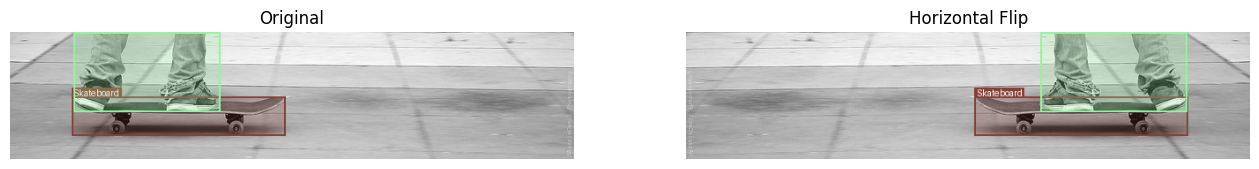

In [6]:
# Test Horizontal Flip
from yolo.data.augmentation.transforms import HorizontalFlip
plot_transform(HorizontalFlip(prob=1.0), "Horizontal Flip")

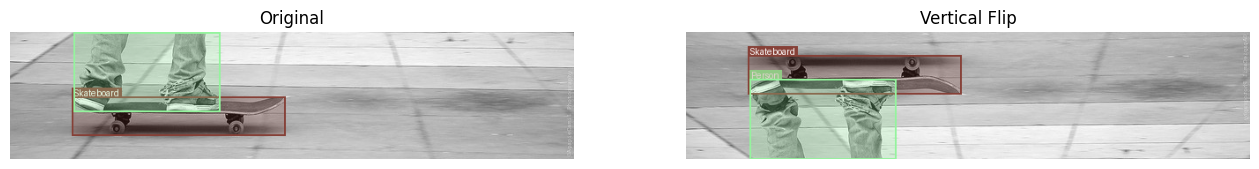

In [7]:
# Test Vertical Flip
from yolo.data.augmentation.transforms import VerticalFlip
plot_transform(VerticalFlip(prob=1.0), "Vertical Flip")

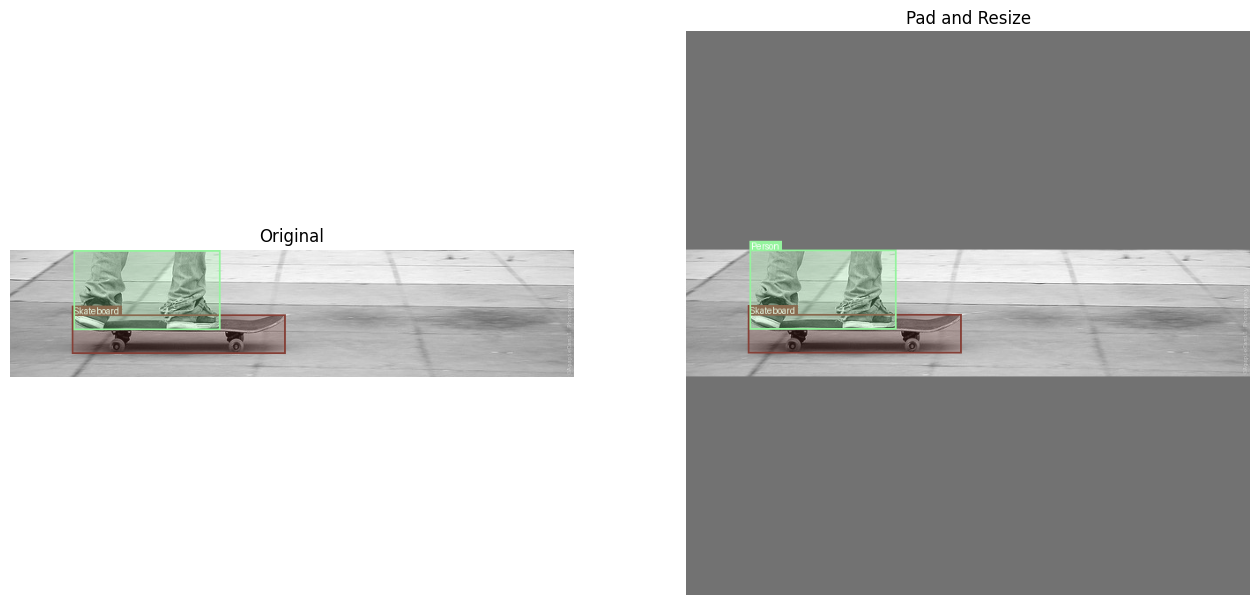

In [8]:
# Test PadAndResize
from yolo.data.augmentation.transforms import PadAndResize
plot_transform(PadAndResize(image_size=(640, 640)), "Pad and Resize")

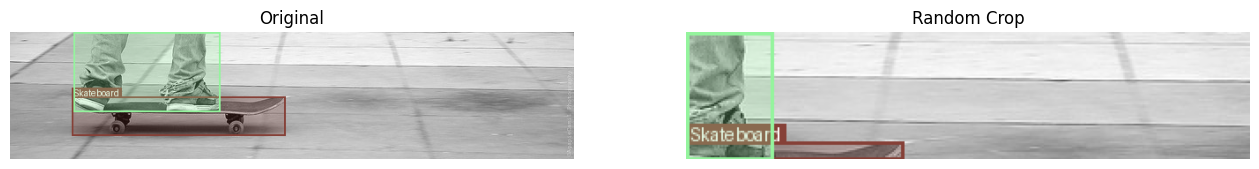

In [9]:
# Test Random Crop
plot_transform(RandomCrop(prob=1.0), "Random Crop")

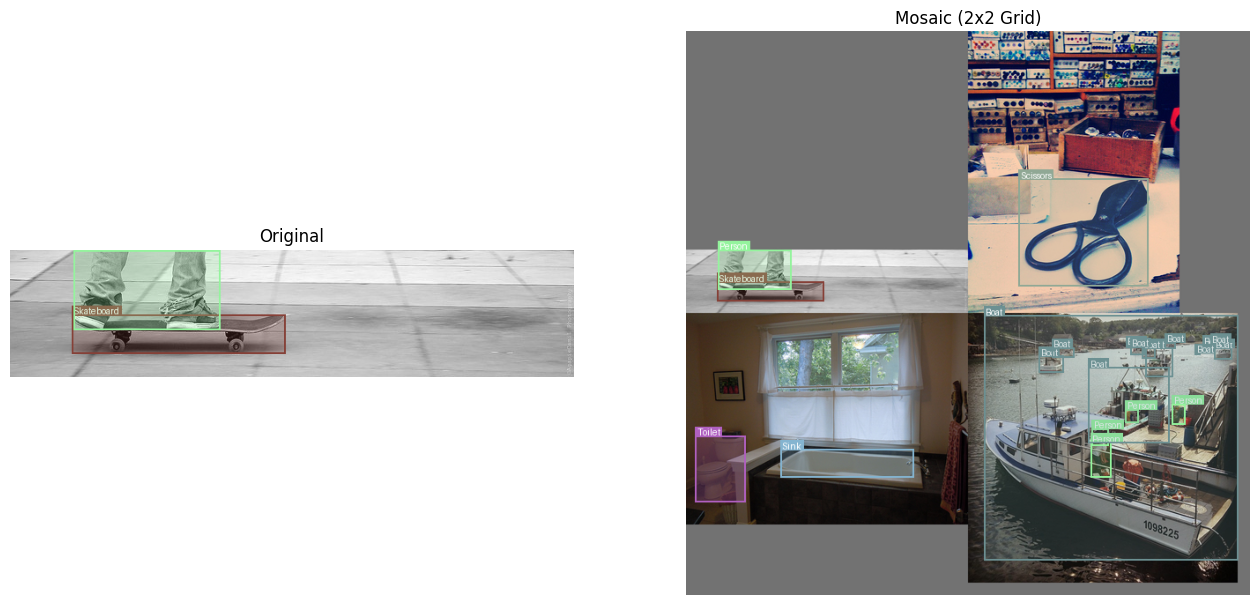

In [10]:
# Test Mosaic (Requires parent injection)
mosaic = Mosaic(prob=1.0).set_parent(dataloader.dataset.transform)
plot_transform(mosaic, "Mosaic (2x2 Grid)")

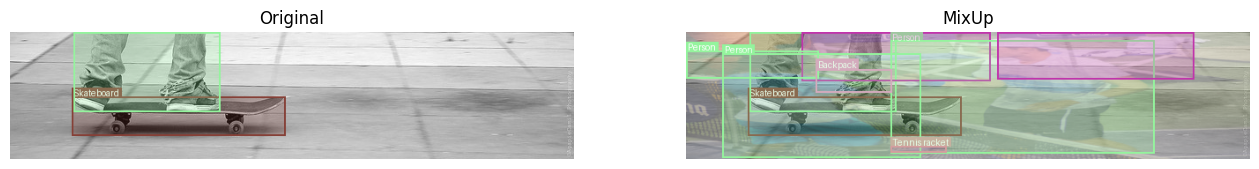

In [11]:
# Test MixUp
mixup = MixUp(prob=1.0).set_parent(dataloader.dataset.transform)
plot_transform(mixup, "MixUp")

In [12]:
num_to_show = min(2, batch.batch_size)
fig, axes = plt.subplots(1, num_to_show, figsize=(16, 8))
if num_to_show == 1: axes = [axes]

for i in range(num_to_show):
    img_tensor = batch.images[i]
    targets = batch.targets[i]
    
    # Filter out empty targets (class -1)
    valid_targets = targets[targets[:, 0] != -1]
    
    img_with_boxes = draw_bboxes(
        img_tensor, 
        valid_targets.tolist(), 
        idx2label=dataset_cfg.class_list
    )
    
    axes[i].imshow(img_with_boxes)
    axes[i].set_title(f"File: {Path(batch.paths[i]).name}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

NameError: name 'batch' is not defined